In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from signature_core_py import *
from processes import *

plt.rcParams['figure.dpi'] = 100
generate_new_images = False
np.random.seed(0xDEADBEEF)

In [15]:
def sig_from_flat(data: np.array, order: int):
    sig = [ np.zeros( (2,)*i ) for i in range(order+1) ]
    curr_idx = 0
    for i in range(len(sig)):
        for index in np.ndindex(sig[i].shape):
            if curr_idx >= data.shape[0]:
                continue
            sig[i][index] = data[curr_idx]
            curr_idx += 1
    return sig

In [16]:
def loss_sig(sig_data: np.array, time_grid: np.array, realizations: np.array, brownians_sigs, beta_1: float, beta_2: float, sig_order):
    """
        sig: signature whose loss will be returned
        time_grid: list of 1D increasing time values, ex: np.linspace(0,1,100). Must match the [time_grid] used in [realizations] and [brownians]
        realizations: realization of the process = f(time_grid, brownians), size = (num_simulations, num_times)
        brownians: signatures of brownian realization list of (num_simulations) lists of sig_orders of np.arrays of increasing orders w/ first dim = num_times
        beta_1, beta_2: L1 regularization parameters, the bigger, the less biased / over-fitted

        Returns a float loss
    """

    assert len(brownians_sigs) == realizations.shape[0]
    
    sig = sig_from_flat(sig_data, sig_order)

    loss_value = 0

    for i in range(len(brownians_sigs)):
        b = brownians_sigs[i]
        realization_approx = bracket_with_process(sig, b)
        loss_value =+ (( realizations[i, :] - realization_approx )**2).sum() + (beta_1 * np.abs(sig_data) + beta_2 * sig_data**2).sum()

    return loss_value / realizations.shape[0]

In [ ]:
n = 100
time_grid = np.arange(start=0, stop=n+1) / n
brownians = generate_brownian(time_grid, 1)
brownian_sig = signature(np.array([time_grid, brownians.flatten()]), 6)

time_grid_2y = np.linspace(0.0, 2.0, 100)
brownians = generate_brownian(time_grid_2y, n)
beta_1, beta_2 = 0.1, 0.1
x0 = 0

results = pd.DataFrame(columns=["Order", "6mo", "12mo", "18mo", "24mo"])

for sig_order in [2, 4, 6]:
	# Generate the signature and true ornstein processes
	brownians_sig = [signature(np.array([time_grid_2y, b.flatten()]), sig_order) for b in brownians]
	(ornsteins, _) = generate_naive_ornstein_sig(time_grid_2y, brownians, brownian_sig, x0, kappa=4, etha=2, theta=0.25, max_sig_order=sig_order)
	true_ornstein_signature = compute_ornstein_uhlenbeck_signature(x0, kappa=4, etha=2, theta=0.25, exp_order=sig_order )
	ornstein_sig = compute_ornstein_uhlenbeck_signature(x0, kappa=4, etha=2, theta=0.25, exp_order=sig_order)
	data_size = sum([2**i for i in range(sig_order+1)])
    
	# Define objective function
	def loss_func(sig_data):
		return loss_sig(sig_data, time_grid_2y, ornsteins, brownians_sig, beta_1, beta_2, sig_order)

	# Fit the signature
	opt_x0 = np.ones(data_size) * 0
	res = scipy.optimize.minimize(loss_func, opt_x0, tol=0.01)
	fitted_sig = sig_from_flat(res.x,sig_order)
	
	# Compute MSE
	process_approx = bracket_with_process(fitted_sig, brownians_sig[0])

	# Number of samples for an interval of 6 months
	s6m = len(time_grid_2y) // 4
	mse = ( (ornsteins[0] - process_approx) ** 2 ).cumsum()[[s6m, 2*s6m, 3*s6m, -1]]
	mse /= np.array([s6m, 2*s6m, 3*s6m, 4*s6m])
    
	results.loc[len(results)] = [sig_order] + list(mse)

In [18]:
display(Markdown(results.to_markdown()))

|    |   Order |       6mo |      12mo |      18mo |     24mo |
|---:|--------:|----------:|----------:|----------:|---------:|
|  0 |       2 | 0.0803505 | 0.0957977 | 0.776802  | 1.75639  |
|  1 |       4 | 0.0445966 | 0.0522907 | 0.0766777 | 0.169496 |
|  2 |       6 | 0.0418327 | 0.048421  | 0.0720694 | 0.13568  |

Loss: 0.03, Abs Error: 4097.10


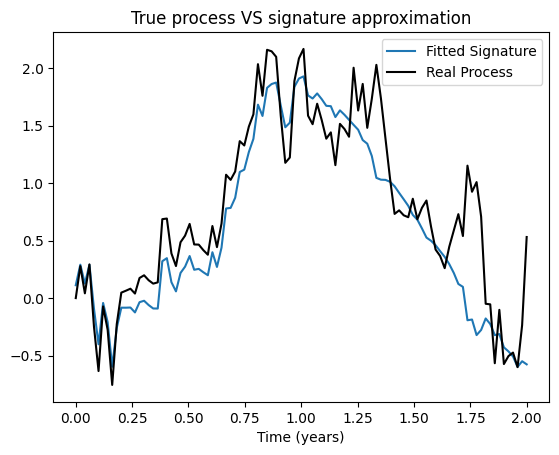

In [19]:
loss = loss_sig(res.x, time_grid_2y, ornsteins, brownians_sig, beta_1, beta_2, sig_order)
absolute_error = sum([ np.sum(np.abs(a-b)) for (a,b) in zip(ornstein_sig, fitted_sig)])

print(f"Loss: {loss:.2f}, Abs Error: {absolute_error:.2f}")

process_approx = bracket_with_process(fitted_sig, brownians_sig[0])
plt.plot(time_grid_2y, process_approx, label="Fitted Signature")
plt.plot(time_grid_2y, ornsteins[0], label="Real Process", color="black")
plt.legend()
plt.xlabel("Time (years)")
plt.title("True process VS signature approximation")
plt.show()